<center>
    <img src="https://digip.unibg.it/sites/dip3/files/logo-dip-it.svg">
    <h1><b>Previsione del K/D Ratio in Valorant</b> - AA 2025/2026</h1>
    <h2>🗾 Gruppo Hayabusa 🗾​</h2>
    <h3>Spampatti Nicolò, Piffari Matteo, Ghilardi Giovanni, Magri Marco</h3>
</center>

# Presentazione del dataset

Il dataset oggetto di analisi raccoglie statistiche dettagliate relative al VCT 2024. I dati offrono un livello di dettaglio elevato, permettendo di analizzare le performance dei singoli pro player non solo a livello di match complessivo, ma scendendo nel dettaglio delle singole mappe, agenti e delle fasi di gioco, oltre alle metriche standard di rendimento (K/D, ACS, ADR).

## Obiettivo

Capire quali fattori tecnici e tattici prevedono un K/D elevato.

# Importazione delle librerie

In [58]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from tabulate import tabulate
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Importazione dei dati

In [59]:
# importazione del dataset
data = pl.read_csv(
    source = "valorant.csv",
    encoding = "latin-1",
    truncate_ragged_lines = True
)

# visualizzazione dei nomi delle colonne
print("Colonne disponibili nel dataset:")
print(data.columns)

Colonne disponibili nel dataset:
['Tournament;Stage;Match.Type;Match.Name;Map;Player.Team;Player;Enemy.Team;Enemy;Player.Kills;Enemy.Kills;Difference;Kill.Type;Agents;Rating;Average.Combat.Score;Kills;Deaths;Assists;Kills...Deaths..KD.;Kill..Assist..Trade..Survive..;Average.Damage.Per.Round;Headshot..;First.Kills;First.Deaths;Kills...Deaths..FKD.;Side;Team.B;Team.A.Score;Team.B.Score;Match.Result;Elimination;Detonated;Defused;Time.Expiry..No.Plant.;Eliminated;Defused.Failed;Detonation.Denied;Time.Expiry..Failed.to.Plant.;RESTO']


In [60]:
# importazione del dataset
data = pl.read_csv(
    source = "valorant_K-D.csv",
    encoding = "latin-1",
    truncate_ragged_lines = True,
    separator = ";"
)

# rinomino prima, così poi le liste usano già i nomi corretti
data = data.rename({
    "Player.Team": "Player Team",
    "Team.B": "Enemy Team",
    "Average.Combat.Score": "Average Combat Score",
    "Kills...Deaths..KD.":"KD",
    "Defused.Failed": "Defused Failed",
    "Detonation.Denied": "Detonation Denied",
    "Match.Result": "Match Result",
    "Average.Damage.Per.Round": "Avg Damage Per Round",
    "Headshot.." : "Headshot"
})

# correzione dei tipi di dato - ora con i nomi aggiornati
categorical_columns = [
    "Match.Type",
    "Map",
    "Kill.Type",
    "Player Team",
    "Player",
    "Role",
    "Enemy Team",
    "Tournament"
]
numeric_columns = [
    "Rating",
    "Average Combat Score",
    "Kills",
    "Deaths",
    "Assists",
    "KD",
    "Avg Damage Per Round",
    "Headshot",
    "First.Kills",
    "First.Deaths",
    "Elimination",
    "Detonated",
    "Defused",
    "Defused Failed",
    "Detonation Denied", 
    "Match Result"
]

data = data.drop(
    "Enemy",
    "Player.Kills",
    "Enemy.Kills",
    "Difference",
    "Enemy.Team",
    "Side",
    "Team.A.Score",
    "Team.B.Score",
    "Time.Expiry..Failed.to.Plant.",
    "Time.Expiry..No.Plant.",
    "Kill..Assist..Trade..Survive..",
    "Stage",
    "Match.Name",
    "Kills...Deaths..FKD.",
    "Eliminated"
)

# 1. Trasformazione Match Result (rimane Int64, ottimo per la statistica)
data = data.with_columns(
    pl.when(pl.col("Match Result").str.contains(pl.col("Player Team")))
    .then(1)
    .otherwise(0)
    .cast(pl.Int64)
    .alias("Match Result")
)

# 2. Conversione numerica di massa (escludendo Match Result se già processato)
# Creiamo una lista di espressioni per gestire tutte le colonne in una volta sola
float_expressions = [
    pl.col(col).cast(pl.String).str.replace(",", ".").cast(pl.Float64).alias(col)
    for col in numeric_columns if col in data.columns
]

data = data.with_columns(float_expressions)

agent_roles = {
    # duelists
    'jett': 'duelist', 'raze': 'duelist', 'reyna': 'duelist', 
    'phoenix': 'duelist', 'yoru': 'duelist', 'neon': 'duelist', 'iso': 'duelist',
    # initiators
    'sova': 'initiator', 'breach': 'initiator', 'skye': 'initiator', 
    'kayo': 'initiator', 'fade': 'initiator', 'gekko': 'initiator',
    # controllers
    'omen': 'controller', 'brimstone': 'controller', 'viper': 'controller', 
    'astra': 'controller', 'harbor': 'controller', 'clove': 'controller',
    # sentinels
    'sage': 'sentinel', 'cypher': 'sentinel', 'killjoy': 'sentinel', 
    'chamber': 'sentinel', 'deadlock': 'sentinel', 'vyse': 'sentinel'
}

# Creazione della colonna 'Role' usando replace
data = data.with_columns(
    pl.col("Agents").replace(agent_roles).alias("Role")
)

# Visualizzazione
print(data.head(10))


shape: (10, 25)
┌────────────┬────────────┬────────┬────────────┬───┬─────────┬────────────┬───────────┬───────────┐
│ Tournament ┆ Match.Type ┆ Map    ┆ Player     ┆ … ┆ Defused ┆ Defused    ┆ Detonatio ┆ Role      │
│ ---        ┆ ---        ┆ ---    ┆ Team       ┆   ┆ ---     ┆ Failed     ┆ n Denied  ┆ ---       │
│ str        ┆ str        ┆ str    ┆ ---        ┆   ┆ f64     ┆ ---        ┆ ---       ┆ str       │
│            ┆            ┆        ┆ str        ┆   ┆         ┆ f64        ┆ f64       ┆           │
╞════════════╪════════════╪════════╪════════════╪═══╪═════════╪════════════╪═══════════╪═══════════╡
│ Valorant   ┆ Upper Quar ┆ Icebox ┆ G2 Esports ┆ … ┆ 3.0     ┆ 1.0        ┆ 4.0       ┆ initiator │
│ Champions  ┆ terfinals  ┆        ┆            ┆   ┆         ┆            ┆           ┆           │
│ 2024       ┆            ┆        ┆            ┆   ┆         ┆            ┆           ┆           │
│ Valorant   ┆ Upper Quar ┆ Icebox ┆ G2 Esports ┆ … ┆ 3.0     ┆ 1.0        

# EDA (Exploratory Data Analysis)

## Distribuzione delle variabili numeriche e correlogramma
Valuto le statistiche (media, sd, varianza) e la distribuzione, analisi preliminare

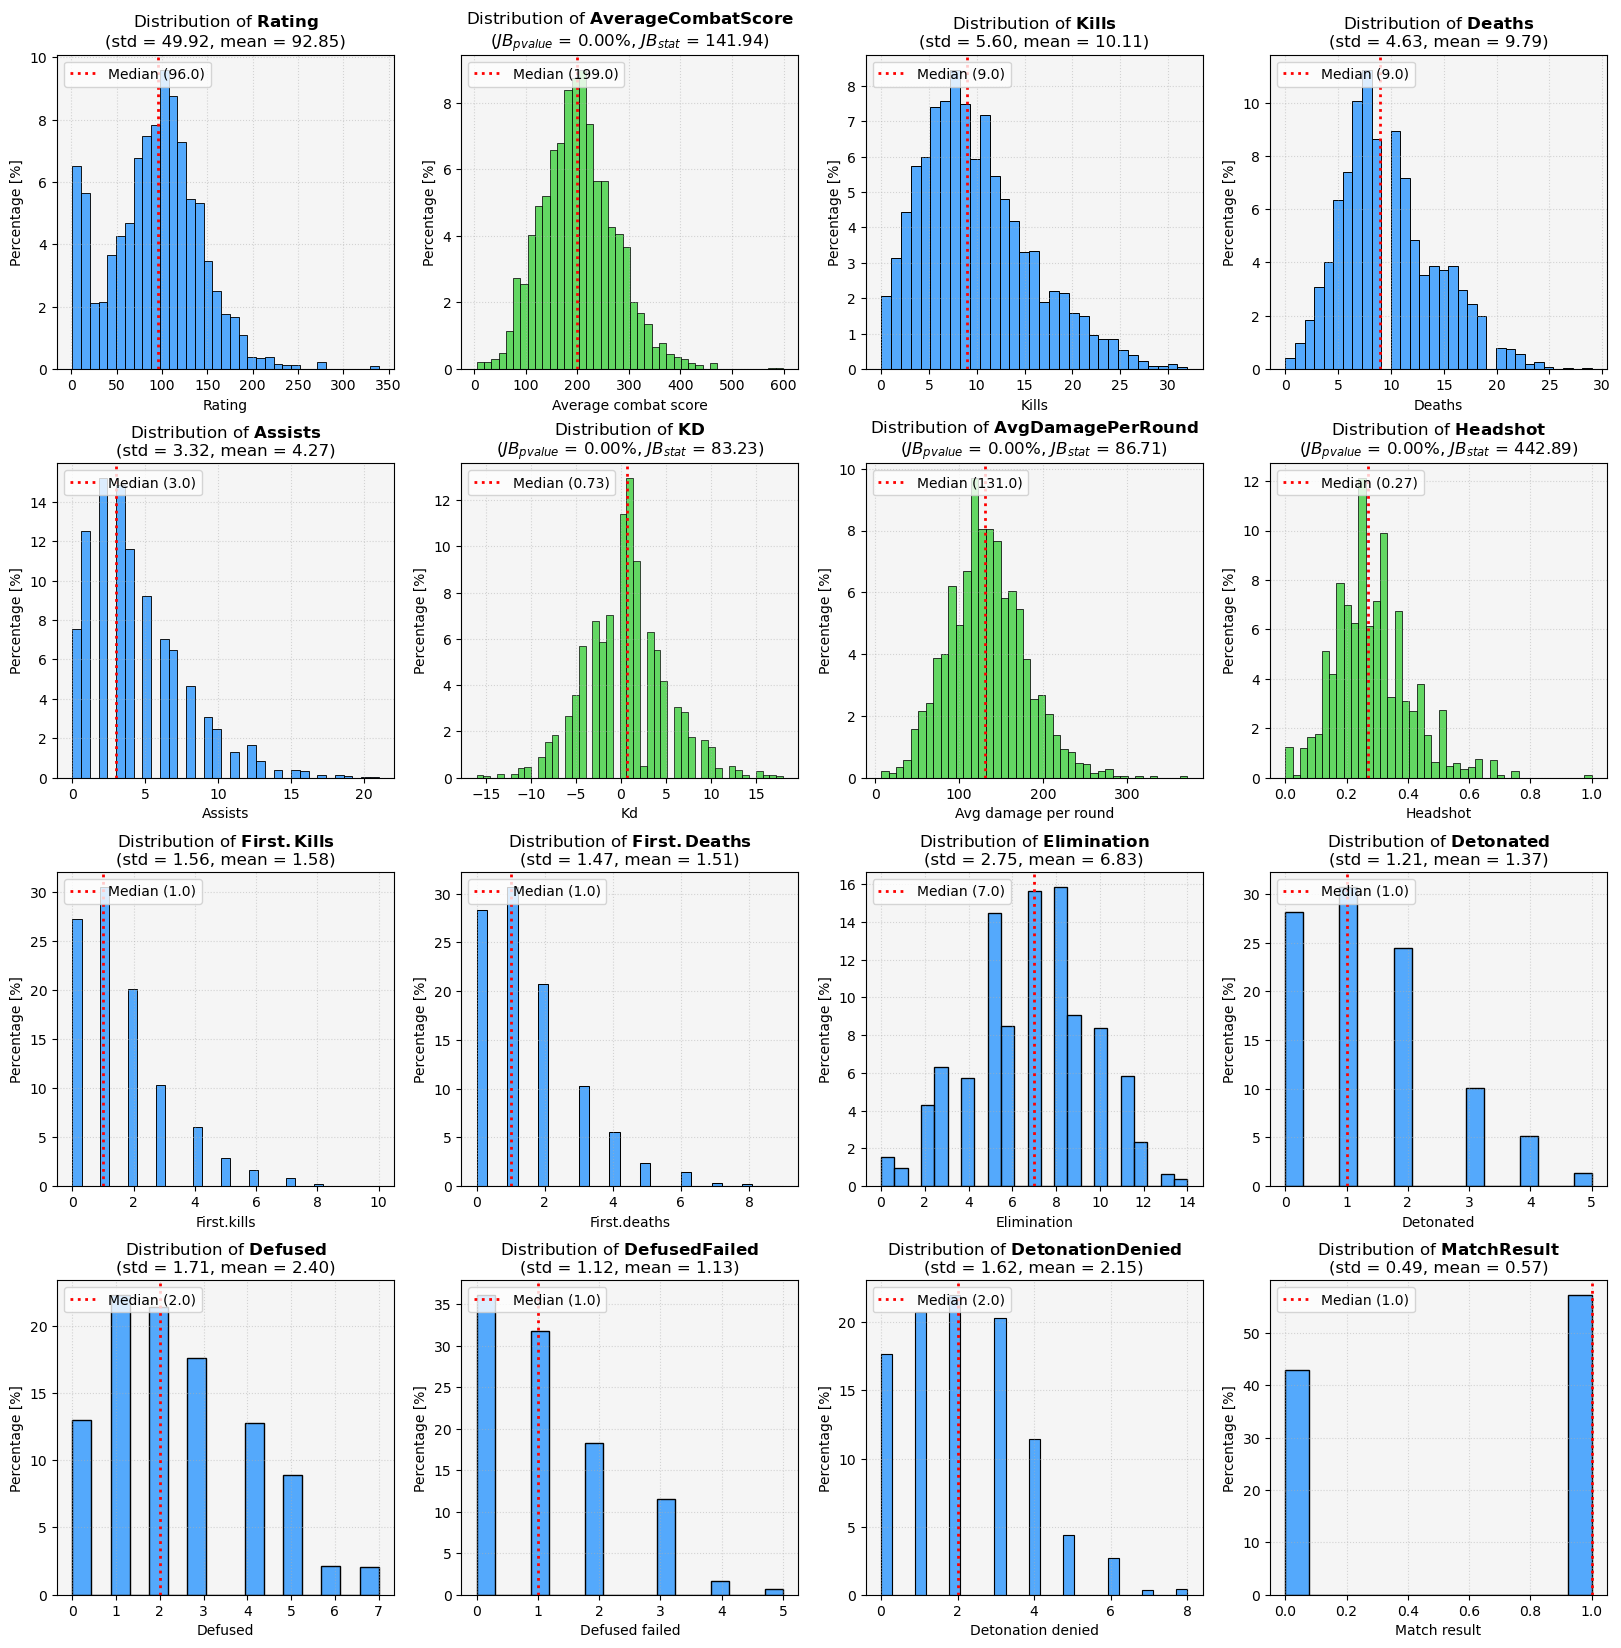

In [61]:
# layout
ncols = 4
nrows = 4
fig, axes = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize=(20, nrows * 5)
)
fig.subplots_adjust(
    hspace = .3,
    wspace = .2
)
axes = axes.flatten()

normTest = ["Average Combat Score", "KD", "Avg Damage Per Round", "Headshot"]

for i, variable_i in enumerate(numeric_columns):
    var_name = variable_i.replace('_', ' \\ ')

    sns.histplot(
        data = data.to_pandas(),
        x = variable_i,
        stat = "percent",
        color = "limegreen" if variable_i in normTest else "dodgerblue",
        ax = axes[i]
    )
    median_i = data[variable_i].median()
    axes[i].axvline(
        median_i,
        color = "red",
        ls = ":",
        lw = 2,
        label = f"Median ({median_i})"
    )
    axes[i].set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylabel = "Percentage [%]",
        facecolor = "whitesmoke"
    )
    axes[i].grid(
        ls = ":",
        alpha = .5
    )
    axes[i].legend(
        loc = "upper left"
    )

    # test di normalità di Jarque-Bera
    if variable_i in normTest:
        statistic, p_value = stats.jarque_bera(data[variable_i].to_list())
        axes[i].set_title(
            f"Distribution of $\\mathbf{{{var_name}}}$" +
            f"\n($JB_{{pvalue}}$ = {p_value*100:.2f}%, $JB_{{stat}}$ = {statistic:.2f})",
            fontsize = 12
        )
    else:
        axes[i].set_title(
            f"Distribution of $\\mathbf{{{var_name}}}$" +
            f"\n(std = {data[variable_i].std():.2f}, mean = {data[variable_i].mean():.2f})",
            fontsize = 12
        )


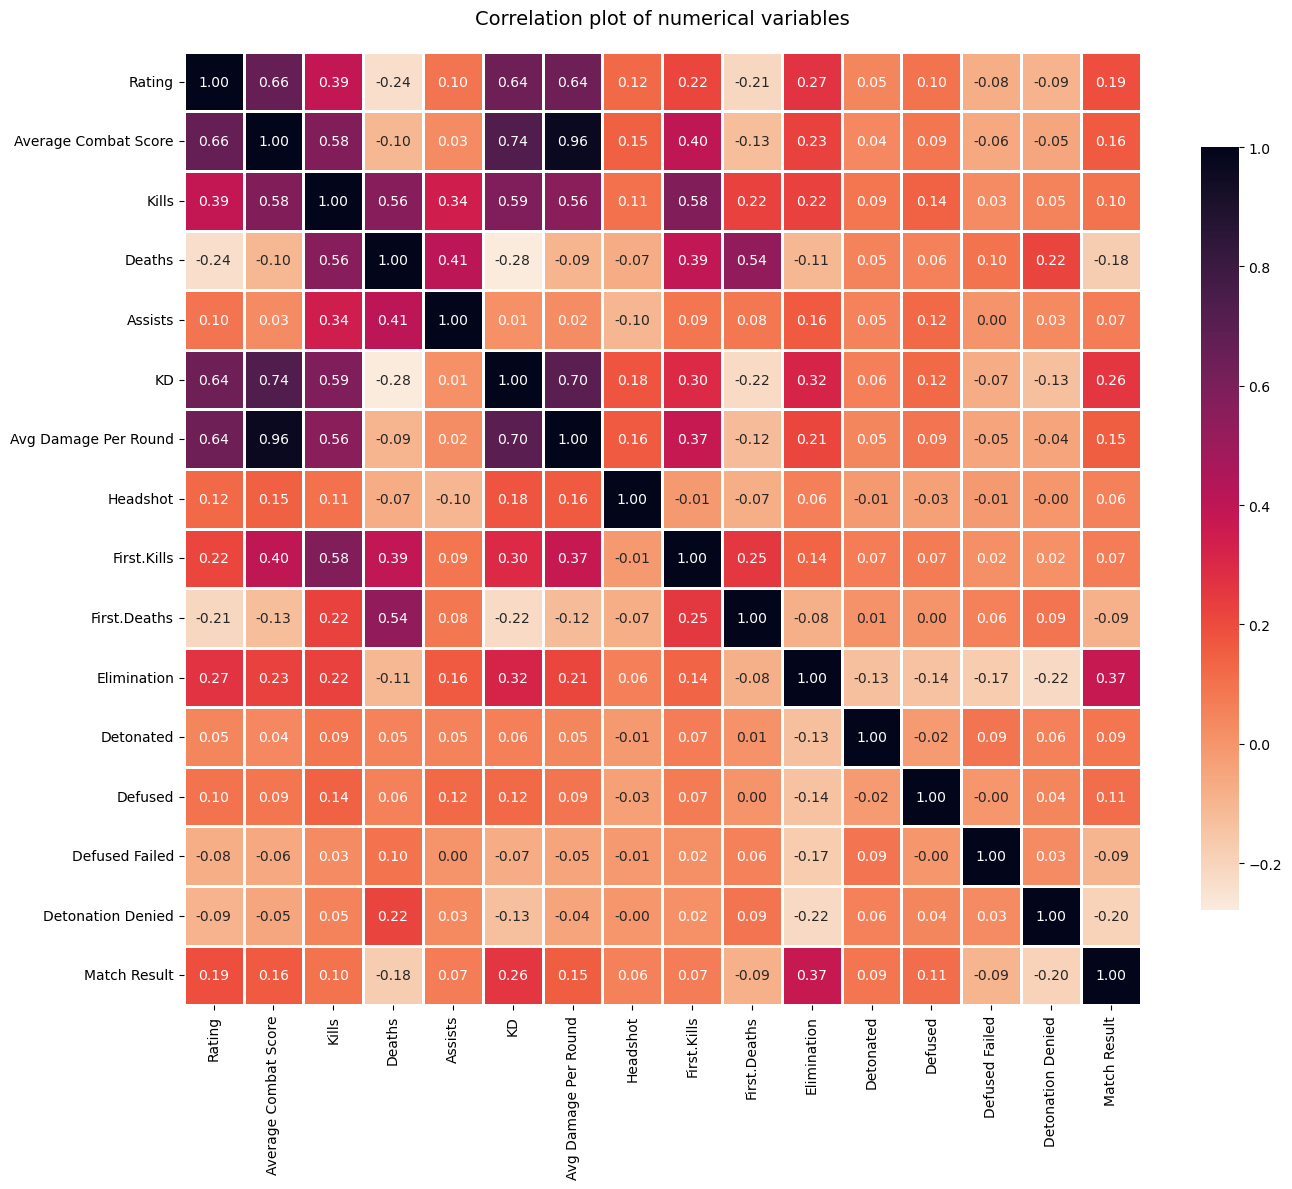

In [62]:
# Correlogramma - Figura grande separata
fig, ax = plt.subplots(figsize=(14, 12))

corr = data[numeric_columns].to_pandas().corr()
sns.heatmap(
    data = corr,
    annot = True,
    fmt = ".2f",
    cmap = "rocket_r",
    linewidths = 1,
    cbar_kws = {"shrink": 0.8},
    ax = ax
)
ax.tick_params(
    "y",
    rotation = 0
)
ax.set_title(
    "Correlation plot of numerical variables",
    size = 14,
    pad = 20
)
plt.tight_layout()

## Legami tra le variabili numeriche e la variabile target
Capire se una variabile influisce sul risultato finale (in questo caso lo score)

### Variabili numeriche per il KD

In [ ]:
numeric_KD_columns = ["Avg Damage Per Round", "Headshot", "First.Kills", "First.Deaths", "Defused", "Defused Failed", "Detonation Denied"]

# layout
ncols = 4
nrows = 2
fig, axes = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize=(20, nrows * 5)
)
fig.subplots_adjust(
    hspace = .3,
    wspace = .2
)
axes = axes.flatten()

for i, variable_i in enumerate(numeric_KD_columns):
    sns.regplot(
        data = data.unique(
            subset = [variable_i, "KD"]
        ),
        x = variable_i,
        y = "KD",
        scatter_kws = {
            "color": "dodgerblue",
            "alpha": .5
        },
        line_kws = {
            "color": "black",
            "ls": ":",
            "lw": 2
        },
        ci = None,
        ax = axes[i]
    )
    axes[i].set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylim = (-20, 50),
        ylabel = "KD",
        facecolor = "whitesmoke"
    )
    axes[i].grid(
        ls = ":",
        alpha = .5
    )

    # calcolo dei coefficienti di correlazione
    r_pearson = stats.pearsonr(data[variable_i].to_list(), data["KD"].to_list())
    r_spearman = stats.spearmanr(data[variable_i].to_list(), data["KD"].to_list())
    axes[i].set_title(
        f"KD vs $\\mathbf{{{variable_i}}}$"
        + f"\n($r_{{Pearson}}$ = {r_pearson[0]:.2f}, $r_{{Spearman}}$ = {r_spearman.correlation:.2f})",
        fontsize = 12
    )

# rimozione delle figure vuote
for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes[j])

### Conclusioni
Non si nota un grande legame tra First Kills e KD, (Stimatore ha un p-value di 0.50)

In [ ]:
numeric_KD_columns.remove("Defused Failed")

## Distribuzione delle variabili categoriche

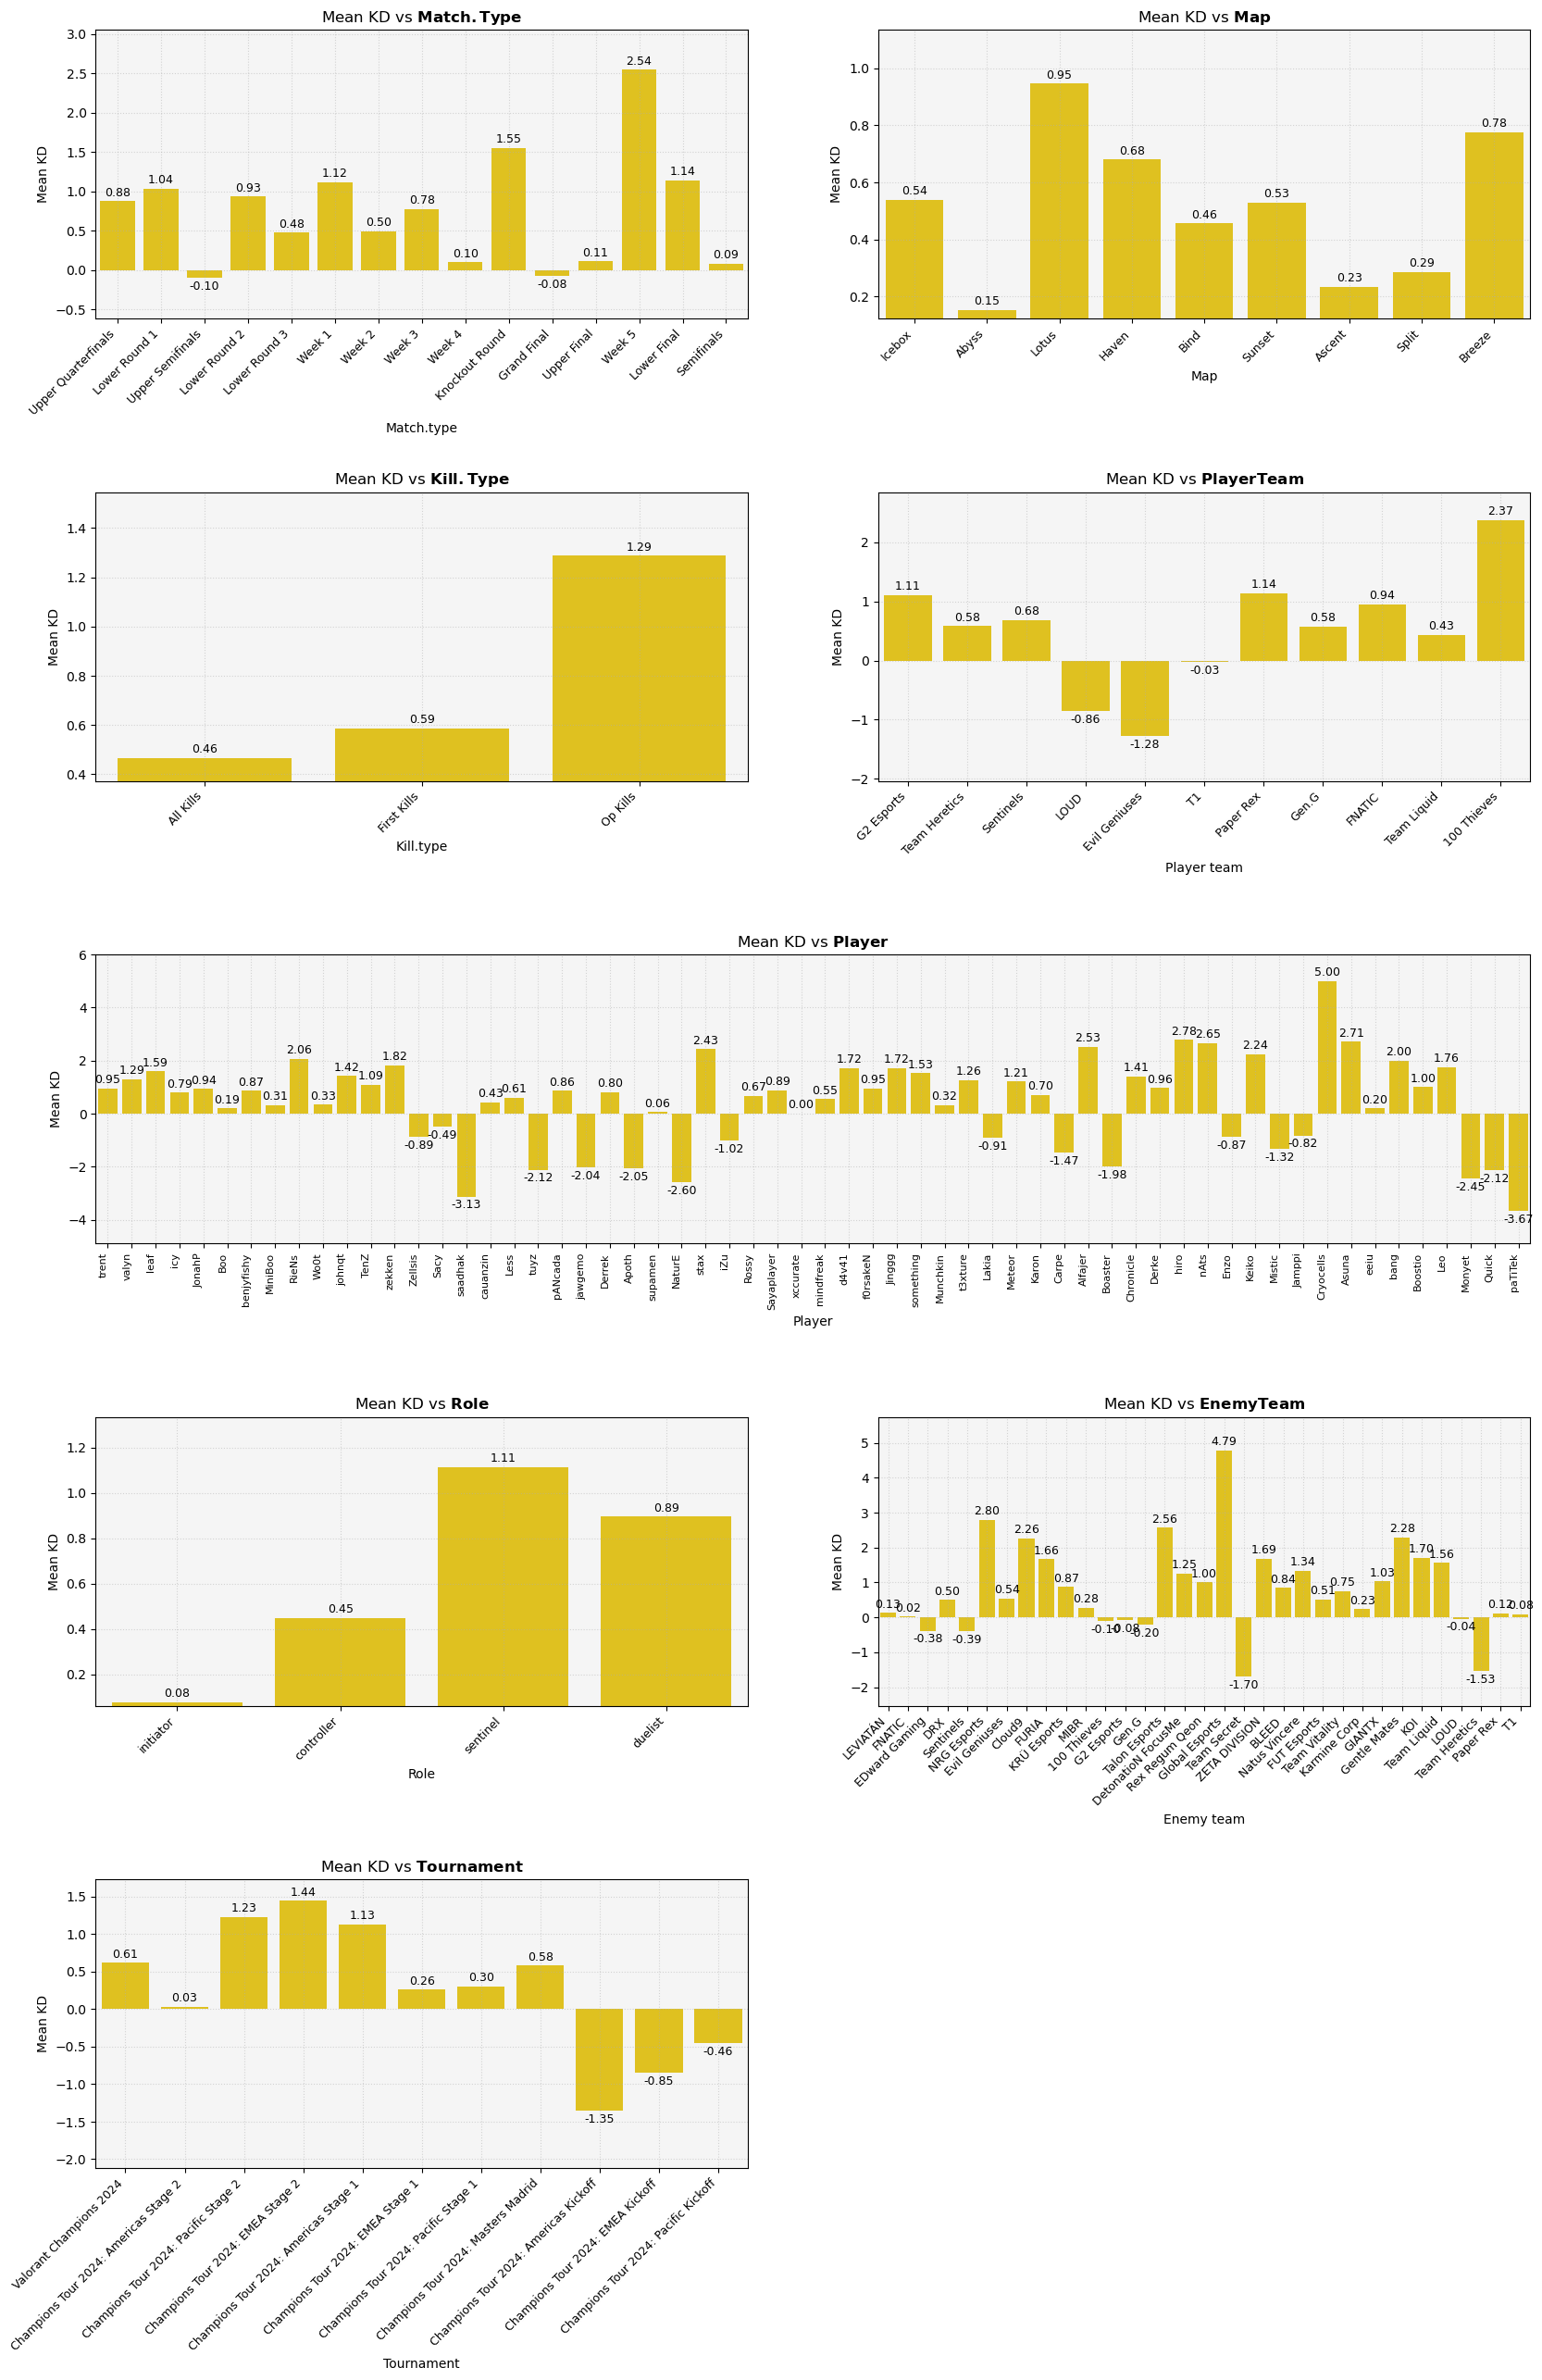

In [ ]:
ncols = 2
nrows = 5
fig = plt.figure(figsize=(20, nrows * 6))
gs = fig.add_gridspec(nrows, ncols, hspace=0.6, wspace=0.2)

subplot_idx = 0

for i, variable_i in enumerate(categorical_columns):
    stat_type = "Mean"         # Etichetta testuale
    est_func = "mean"          # Funzione per Seaborn (stringa o np.mean)
    # Calcolo del max in Polars usando la MEDIA
    kd_stats = data.group_by(variable_i).agg(pl.col("KD").mean())["KD"]
    
    max_kd = kd_stats.max()
    min_kd = kd_stats.min()

    # --- 2. LOGICA GRIGLIA (Gestione spazi) ---
    if variable_i == "Player":
        # Se siamo a metà riga, andiamo a capo per dare spazio intero ai Player
        if subplot_idx % ncols != 0:
            subplot_idx += 1
            
        current_row = subplot_idx // ncols
        if current_row < nrows:
            ax = fig.add_subplot(gs[current_row, :]) # Occupa tutta la riga (2 col)
            subplot_idx += 2
        else: continue
    else:
        current_row = subplot_idx // ncols
        current_col = subplot_idx % ncols
        if current_row < nrows:
            ax = fig.add_subplot(gs[current_row, current_col]) # Occupa 1 col
            subplot_idx += 1
        else: continue

    # --- 3. PLOTTING DINAMICO ---
    sns.barplot(
        data = data,
        x = variable_i,
        y = "KD",
        estimator = est_func,  # <--- Qui passa np.median o "mean"
        color = "gold",
        errorbar = None,
        ax = ax
    )
    
    # --- 4. ETICHETTE E FORMATTAZIONE ---
    ax.set(
        xlabel = variable_i.capitalize().replace("_", " "),
        ylim = (min_kd * 1.20 - 0.5 if min_kd < 0 else min_kd * 0.8, max_kd * 1.20),
        ylabel = f"{stat_type} KD",  # <--- Aggiorna asse Y (Median KD / Mean KD)
        facecolor = "whitesmoke",
    )
    ax.grid(ls = ":", alpha = .5)
    
    # Etichette sulle barre
    ax.bar_label(
        ax.containers[0],
        fontsize = 9,
        label_type = "edge",
        fmt = "%.2f",
        padding = 2
    )
    
    # Titolo Dinamico
    ax.set_title(f"{stat_type} KD vs $\\mathbf{{{variable_i}}}$", fontsize = 12)
    
    # Rotazione specifica per i Player (che sono tanti)
    if variable_i == "Player":
        ax.tick_params(axis='x', rotation=90, labelsize=8)
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        
    plt.setp(ax.get_xticklabels(), ha='right')

plt.show()

## Test ANOVA per selezionare le variabili categoriche più significative

In [ ]:
# Test Anova sul KD
ANOVA_results = []
for variable_i in categorical_columns:

    ANOVA_table = sm.stats.anova_lm(
        ols(
            formula = f"KD ~ C(Q('{variable_i}'))",
            data = data.to_pandas()
        ).fit(),
        typ = 2
    )
    ANOVA_results.append(
        (variable_i, ANOVA_table.loc[f"C(Q('{variable_i}'))", "PR(>F)"])
    )

# visualizzazione dei risultati del test ANOVA
print(
    tabulate(
        tabular_data = ANOVA_results,
        headers = ["Categorical variable", "ANOVA p-value"],
        tablefmt = "pretty",
        colalign = ["center"] * 2
    )
)

+----------------------+------------------------+
| Categorical variable |     ANOVA p-value      |
+----------------------+------------------------+
|      Match.Type      | 0.0011253443689334289  |
|         Map          |   0.5820902615157624   |
|      Kill.Type       |  0.11463178347651083   |
|     Player Team      | 5.939709890323785e-07  |
|        Player        | 2.9996828219468513e-16 |
|         Role         | 0.0009855141770075853  |
|      Enemy Team      |  5.15437172380197e-08  |
|      Tournament      | 1.3308200994636125e-06 |
+----------------------+------------------------+


Se il valore è minore di 0.05 allora significa che le varie medie (step precedente) siano significativamente diverse, in questo caso sleep_quality e study_method come visto precedentemente

- H0 -> le medie sono uguali
- H1 -> Le medie sono tendenzialmente diverse

# Stima del modello
Modello Regressione Log-Lineare (Poisson)

In [ ]:
# Costruisco la stringa delle variabili numeriche per la formula
numeric_vars = " + ".join([f"Q('{col}')" if " " in col or "." in col else col for col in numeric_KD_columns])

# suddivisione del dataset in train e test set
train_data, test_data = train_test_split(
    data,
    test_size = .3,
    random_state = 42
)

# stima
mhat_kd = ols(
    formula = f"KD ~ {numeric_vars} + C(Role) + C(Q('Enemy Team')) + C(Q('Player Team')) + C(Q('Match.Type'))", # Applico il logaritmo del KD modello con soli valori positivi, il + 1 è per non vavere log di 0
    data = train_data.to_pandas()
).fit()
mhat_kd.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     KD   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     32.97
Date:                Sun, 11 Jan 2026   Prob (F-statistic):          3.74e-242
Time:                        17:36:46   Log-Likelihood:                -3979.1
No. Observations:                1589   AIC:                             8090.
Df Residuals:                    1523   BIC:                             8445.
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -8.1471      1.046     -7.790      0.000     -10.199      -6.096
C(Role)[T.duelist]                           -0.5552      0.235     -2.366      0.018      -1.015      -0.095
C(Role)[T.initiator]                         -0.0616      0.199     -0.310      0.757      -0.452       0.329
C(Role)[T.sentinel]                           0.2628      0.243      1.082      0.279      -0.214       0.739
C(Q('Enemy Team'))[T.BLEED]                   2.9173      1.054      2.767      0.006       0.849       4.985
C(Q('Enemy Team'))[T.Cloud9]                  1.5449      0.777      1.988      0.047       0.020       3.069
C(Q('Enemy Team'))[T.DRX]                     1.2134      0.700      1.734      0.083      -0.159       2.586
C(Q('Enemy Team'))[T.DetonatioN FocusMe]      1.6388      0.839      1.954      0.051      -0.006       3.284
C(Q('Enemy Team'))[T.EDward Gaming]           0.4689      1.042      0.450      0.653      -1.574       2.512
C(Q('Enemy Team'))[T.Evil Geniuses]           0.2069      0.619      0.334      0.738      -1.006       1.420
C(Q('Enemy Team'))[T.FNATIC]                  1.0565      0.712      1.484      0.138      -0.340       2.453
C(Q('Enemy Team'))[T.FURIA]                   1.4210      0.615      2.312      0.021       0.215       2.627
C(Q('Enemy Team'))[T.FUT Esports]             0.7566      0.904      0.837      0.403      -1.017       2.531
C(Q('Enemy Team'))[T.G2 Esports]              0.5563      0.935      0.595      0.552      -1.277       2.389
C(Q('Enemy Team'))[T.GIANTX]                  2.2119      0.928      2.384      0.017       0.392       4.032
C(Q('Enemy Team'))[T.Gen.G]                   0.7512      0.800      0.939      0.348      -0.818       2.320
C(Q('Enemy Team'))[T.Gentle Mates]            2.2381      0.986      2.270      0.023       0.304       4.172
C(Q('Enemy Team'))[T.Global Esports]          4.1985      1.200      3.499      0.000       1.845       6.552
C(Q('Enemy Team'))[T.KOI]                     2.4702      1.010      2.446      0.015       0.490       4.451
C(Q('Enemy Team'))[T.KRÜ Esports]             0.6984      0.815      0.857      0.391      -0.900       2.297
C(Q('Enemy Team'))[T.Karmine Corp]            1.0783      0.889      1.213      0.225      -0.665       2.822
C(Q('Enemy Team'))[T.LEVIATÁN]                0.5526      0.516      1.072      0.284      -0.459       1.564
C(Q('Enemy Team'))[T.LOUD]                    1.1467      0.594      1.930      0.054      -0.019       2.312
C(Q('Enemy Team'))[T.MIBR]                    0.9741      0.603      1.615      0.107      -0.209       2.158
C(Q('Enemy Team'))[T.NRG Esports]             1.7377      1.010      1.721      0.086      -0.243       3.719
C(Q

## Con dati standardizzati

In [ ]:
numeric_vars = " + ".join([f"Q('{col}')" if " " in col or "." in col else col for col in numeric_KD_columns])

# standardizzazione dei dati
std_data = data.clone()
std_data[numeric_KD_columns] = StandardScaler().fit_transform(
    data.select(numeric_KD_columns)
)

# stima
mhat_kd_standard = ols(
    formula = f"KD ~ {numeric_vars} + C(Role) + C(Tournament) + C(Q('Enemy Team')) + C(Q('Player Team')) + C(Q('Match.Type'))",
    data = std_data.to_pandas()
).fit()
mhat_kd_standard.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     KD   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     40.77
Date:                Sun, 11 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:36:51   Log-Likelihood:                -5674.0
No. Observations:                2270   AIC:                         1.150e+04
Df Residuals:                    2194   BIC:                         1.194e+04
Df Model:                          75                                         
Covariance Type:            nonrobust                                         
==========================================================================================================================
                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                  0.0867      1.679      0.052      0.959      -3.205       3.379
C(Role)[T.duelist]                                        -0.6093      0.192     -3.171      0.002      -0.986      -0.232
C(Role)[T.initiator]                                      -0.1758      0.166     -1.062      0.288      -0.500       0.149
C(Role)[T.sentinel]                                        0.1434      0.200      0.718      0.473      -0.248       0.535
C(Tournament)[T.Champions Tour 2024: Americas Stage 1]     1.8683      1.192      1.567      0.117      -0.470       4.206
C(Tournament)[T.Champions Tour 2024: Americas Stage 2]     2.0204      1.028      1.965      0.050       0.004       4.037
C(Tournament)[T.Champions Tour 2024: EMEA Kickoff]        -1.0329      1.950     -0.530      0.596      -4.857       2.791
C(Tournament)[T.Champions Tour 2024: EMEA Stage 1]         2.2439      1.628      1.378      0.168      -0.949       5.436
C(Tournament)[T.Champions Tour 2024: EMEA Stage 2]         2.4889      1.743      1.428      0.154      -0.930       5.908
C(Tournament)[T.Champions Tour 2024: Masters Madrid]       1.8278      0.996      1.836      0.067      -0.125       3.780
C(Tournament)[T.Champions Tour 2024: Pacific Kickoff]     -1.1594      1.382     -0.839      0.402      -3.869       1.550
C(Tournament)[T.Champions Tour 2024: Pacific Stage 1]      0.1346      1.409      0.096      0.924      -2.629       2.898
C(Tournament)[T.Champions Tour 2024: Pacific Stage 2]      0.7594      1.426      0.532      0.594      -2.037       3.556
C(Tournament)[T.Valorant Champions 2024]                   3.1922      1.537      2.077      0.038       0.179       6.205
C(Q('Enemy Team'))[T.BLEED]                                3.4495      1.361      2.535      0.011       0.781       6.118
C(Q('Enemy Team'))[T.Cloud9]                               1.6886      0.716      2.358      0.018       0.284       3.093
C(Q('Enemy Team'))[T.DRX]                                  2.6965      1.112      2.425      0.015       0.516       4.877
C(Q('Enemy Team'))[T.DetonatioN FocusMe]                   3.5635      1.143      3.118      0.002       1.323       5.804
C(Q('Enemy Team'))[T.EDward Gaming]                       -1.4145      1.614     -0.876      0.381      -4.579       1.750
C(Q('Enemy Team'))[T.Evil Geniuses]                       -0.3757      0.522     -0.720      0.471      -1.399       0.647
C(Q('Enemy Team'))[T.FNATIC]                               0.6633      0.958      0.692      0.489      -1.216       2.543
C(Q('Enemy Team'))[T.FURIA]                                1.3457      0.507      2.657      0.008       0.352       2.339
C(Q('Ene

# Analisi dei residui

Text(0.5, 1.0, '(Total) autocorrelation function of $\\mathbf{residuals}$')

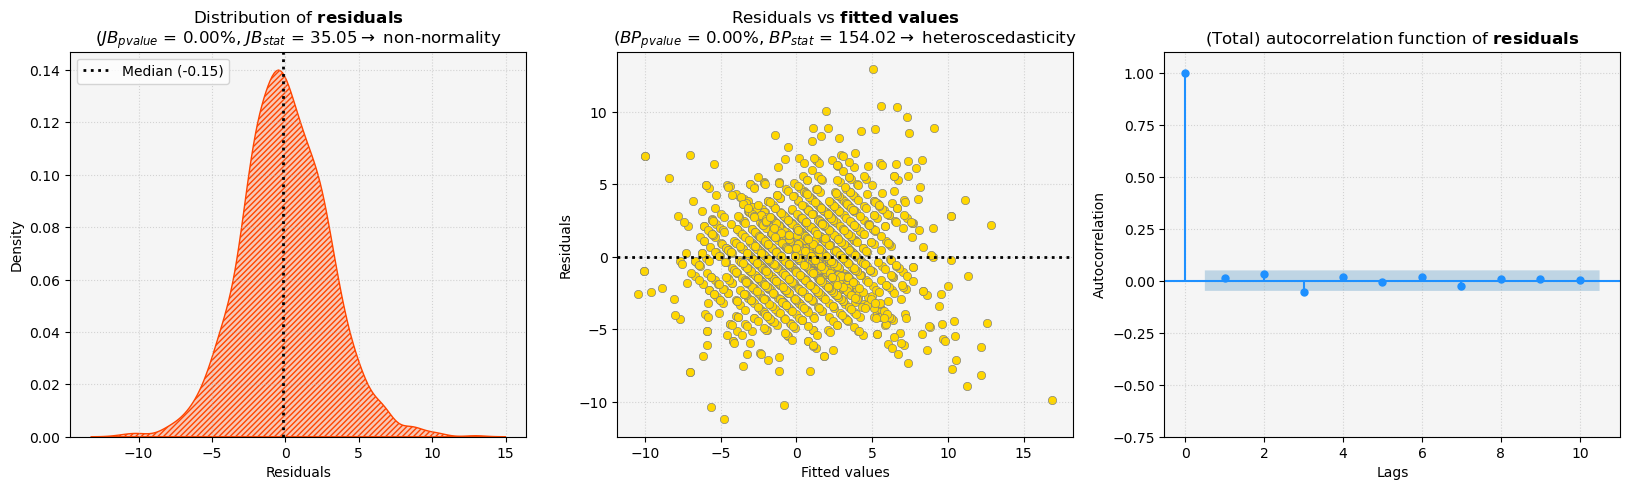

In [ ]:
# layout
ncols = 3
nrows = 1
fig, axes = plt.subplots(
    nrows = nrows,
    ncols = ncols,
    figsize=(20, nrows * 5)
)


# distribuzione dei residui
sns.kdeplot(
    x = mhat_kd.resid,
    color = "orangered",
    fill = True,
    hatch = "//////",
    ax = axes[0]
)
median_i = pl.Series(mhat_kd.resid).median()
axes[0].axvline(
    median_i,
    color = "black",
    ls = ":",
    lw = 2,
    label = f"Median ({median_i:.2f})"
)
axes[0].set(
    xlabel = "Residuals",
    ylabel = "Density",
    facecolor = "whitesmoke"
)
axes[0].grid(
    ls = ":",
    alpha = .5
)
axes[0].legend(
    loc = "upper left"
)

# test di normalità di Jarque-Bera per i residui
jb_stat, jb_pvalue = stats.jarque_bera(mhat_kd.resid)
axes[0].set_title(
    f"Distribution of $\\mathbf{{residuals}}$" + 
    f"\n($JB_{{pvalue}}$ = {jb_pvalue*100:.2f}%, $JB_{{stat}}$ = {jb_stat:.2f}"
    + f"$\\rightarrow$ {'normality' if jb_pvalue > 0.05 else 'non-normality'}",
    fontsize = 12
)

# residui vs valori predetti
sns.scatterplot(
    x = mhat_kd.fittedvalues,
    y = mhat_kd.resid,
    color = "gold",
    edgecolor = "grey",
    ax = axes[1]
)
axes[1].set(
    xlabel = "Fitted values",
    ylabel = "Residuals",
    facecolor = "whitesmoke"
)
axes[1].axhline(
    0,
    color = "black",
    ls = ":",
    lw = 2
)
axes[1].grid(
    ls = ":",
    alpha = .5
)

# test di Breusch-Pagan per l'omocedasticità dei residui
bp_stat, bp_pvalue, _, _ = het_breuschpagan(
    resid = mhat_kd.resid,
    exog_het = mhat_kd.model.exog
)
axes[1].set_title(
    f"Residuals vs $\\mathbf{{fitted \\ values}}$"
    f"\n($BP_{{pvalue}}$ = {bp_pvalue*100:.2f}%, $BP_{{stat}}$ = {bp_stat:.2f}"
    + f"$\\rightarrow$ {'homoscedasticity' if bp_pvalue > 0.05 else 'heteroscedasticity'}",
    fontsize = 12
)

# funzione di autocorrelazione (totale)
plot_acf(
    x = mhat_kd.resid,
    lags = 10,
    bartlett_confint = True,
    color = "dodgerblue",
    vlines_kwargs = {
        "colors": "dodgerblue",
    },
    ax = axes[2]
)
axes[2].set(
    xlabel = "Lags",
    ylabel = "Autocorrelation",
    ylim = (-.75, 1.1),
    facecolor = "whitesmoke"
)
axes[2].grid(
    ls = ":",
    alpha = .5
)
axes[2].set_title(
    f"(Total) autocorrelation function of $\\mathbf{{residuals}}$",
    fontsize = 12
)

# Validazione del modello

In [ ]:
print(
    "Linear Regression validation results (KD):\n" + tabulate(
        tabular_data = [
            [
                "R2 (train)", f"{mhat_kd.rsquared:.4f}",
            ],
            [
                "RMSE (train)", f"{np.sqrt(mean_squared_error(train_data['KD'].to_list(), mhat_kd.fittedvalues)):.4f}",
            ],
            [
                "RMSE (test)", f"{np.sqrt(mean_squared_error(test_data['KD'].to_list(), mhat_kd.predict(test_data.to_pandas()))):.4f}",
            ],
            [
                "MAE (train)", f"{mean_absolute_error(train_data['KD'].to_list(), mhat_kd.fittedvalues):.4f}",
            ],
            [
                "MAE (test)", f"{mean_absolute_error(test_data['KD'].to_list(), mhat_kd.predict(test_data.to_pandas())):.4f}",
            ]
        ],
        headers = ["Metric", "Value"],
        tablefmt = "pretty",
        colalign = ["center"] * 2
    )
)

Linear Regression validation results (KD):
+--------------+--------+
|    Metric    | Value  |
+--------------+--------+
|  R2 (train)  | 0.5845 |
| RMSE (train) | 2.9601 |
| RMSE (test)  | 3.0723 |
| MAE (train)  | 2.3117 |
|  MAE (test)  | 2.3959 |
+--------------+--------+


## Usiamo il modello per creare Previsioni

In [ ]:
nuovo_dato = pd.DataFrame([{
    'Avg Damage Per Round': 500,
    'Headshot': 0.12,
    'First.Deaths': 10,
    'Role': 'duelist',
    'Enemy Team': 'Paper Rex',
    'Match.Type': 'Grand Final',
    'Defused': 7, # Defusi in difesa
    'First.Kills': 1, 
    "Player Team": "FNATIC",
    "Detonation Denied": 0 # Defusati in attacco
}])

prediction = mhat_kd.predict(nuovo_dato)

min = prediction[0] - 2.3
max = prediction[0] + 2.3

print(f"Previsione K/D: {prediction[0]:.2f}")
print(f"Intervallo K/D: {min:.2f} - {max:.2f}")

Previsione K/D: 5.56
Intervallo K/D: 3.26 - 7.86
